In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def col_sum(df,old,target):
    df[target]+=df[old]
    df.drop(columns=[old],inplace=True)

In [2]:
datas=[]
df=pd.DataFrame()
for i in range(11,18):
    if i<15:
        df0=pd.read_excel(f"compte partis/file20{i}.xlsx",header=[0,1])
    else:
        df0=pd.read_excel(f"compte partis/file20{i}.ods",header=[0,1])
    column=list(df0.columns)
    column[0]='Num parti'
    column[1]=('Nom parti')
    column[2]=('Unité monétaire', 'euro')
    column[next(i for i, col in enumerate(column) if col[0] == 'CR: PRODUITS' and col[1].startswith('Financement public'))]=('CR: PRODUITS', 'Financement public')
    column=[(i[0].strip().lower(),i[1].strip().lower()) if type(i)==tuple else i.strip().lower() for i in column]
    # for j,i in enumerate(column):
    #     if i[0]=='Unité monétaire':
    #         column[j]=(i[0],'(par défaut euro, changer si F.CFP)')
    #     if 'Financement public' in i[1]:
    #         column[j]=(i[0],i[1][:-9])
    df0.fillna(0,inplace=True)
    df0.columns=column
    #df0.drop(0,inplace=True)
    #df0.reset_index(inplace=True)
    #df0.drop(columns=["index"],inplace=True)
    if ('CR: CHARGES', 'Charges de personnel') in column:
        df0[('CR: CHARGES', 'Charges exceptionnelles')]+=df0[('CR: CHARGES', 'Charges de personnel')]
        df0.drop(columns=[('CR: CHARGES', 'Charges de personnel')],inplace=True)
    df0['année']=2000+i
   
    df=pd.concat([df,df0],ignore_index=True)

del(df0)
    
    # df0.drop(index=list(df0[df0[('Unité monétaire', 'euro')]!='euro'].index),inplace=True)
    # df0.drop(columns=[('Unité monétaire', 'euro')],inplace=True)

    # if ('CR: CHARGES', 'Charges de personnel') in column:
    #     df0[('CR: CHARGES', 'Charges exceptionnelles')]+=df0[('CR: CHARGES', 'Charges de personnel')]
    #     df0.drop(columns=[('CR: CHARGES', 'Charges de personnel')],inplace=True)
    # df0[('année','num')]=i
    # df0[('res', 'total')]=df0[('CR: PRODUITS', 'Total des produits')]-df0[('CR: CHARGES', 'Total des charges')]
    # df0[('CR: CHARGES', 'Dotations aux amortissements et provisions (à saisir si différent de la somme des deux suivants)')]=df0[('CR: CHARGES', '- dotation aux amortissements des charges à répartir')]+df0[('CR: CHARGES', '- dotation aux provisions pour campagnes électorales')]
    # df0.drop(columns=[('CR: CHARGES', 'Total'),('CR: PRODUITS', 'Total'),('CR: PRODUITS', "Résultat d'ensemble (perte)"),('CR: CHARGES', "Résultat d'ensemble (excédent)")],inplace=True)
    # datas.append(df0)
    
    

In [4]:
df.drop(index=list(df[df[('unité monétaire', 'euro')]!='euro'].index),inplace=True)
df.drop(columns=[('unité monétaire', 'euro')],inplace=True)

df[('résultat flux monétaire')]=df[('cr: produits', 'total des produits')]-df[('cr: charges', 'total des charges')]
df[('total flux monétaire')]=abs(df[('cr: produits', 'total des produits')])+abs(df[('cr: charges', 'total des charges')])
#df[('CR: CHARGES', 'Dotations aux amortissements et provisions (à saisir si différent de la somme des deux suivants)')]=df[('CR: CHARGES', '- dotation aux amortissements des charges à répartir')]+df0[('CR: CHARGES', '- dotation aux provisions pour campagnes électorales')]
df.fillna(0,inplace=True)
df.drop(columns=[('cr: charges', 'dotations aux amortissements et provisions (à saisir si différent de la somme des deux suivants)'),('cr: charges', 'total'),('cr: produits', 'total'),('cr: produits', "résultat d'ensemble (perte)"),('cr: charges', "résultat d'ensemble (excédent)")],inplace=True)


In [5]:
num=df[(df[('cr: produits', "total des produits")]==0) & (df[('cr: charges', 'total des charges')]==0)]['num parti']

In [6]:
df['nom parti']=df['nom parti'].apply(lambda x: 'UMP' if 'UNION POUR UN MOUVEMENT POPULAIR' in x else x)

In [7]:
b=df[(df[('cr: produits', "total des produits")]!=0) & (df[('cr: charges', 'total des charges')]!=0)]['num parti']

In [8]:
c=[i for i in list(num) if not i in list(b)]# contient les numéros de partis qui n'ont jamais déclarés de charges ou de produits

In [9]:
df.drop(index=[i for i,j in enumerate(list(df['num parti'].isin(c))) if j],inplace=True)
del(num,c,b)

In [10]:
df.reset_index(inplace=True)
df.drop(columns=['index'],inplace=True)

In [26]:
df

,num parti,nom parti,"(i. - actif immobilisé, immobilisations incorporelles)","(i. - actif immobilisé, ecart d'acquisition)","(i. - actif immobilisé, immobilisations corporelles :)","(i. - actif immobilisé, - terrains et constructions)","(i. - actif immobilisé, - autres immobilisations corporelles)","(i. - actif immobilisé, immobilisations financières :)","(i. - actif immobilisé, participations)","(i. - actif immobilisé, - prêts)",...,"(cr: produits, produits financiers)","(cr: produits, produits exceptionnels)","(cr: produits, reprise sur provisions et amortissements)","(cr: produits, - reprise sur provisions pour campagnes électorales :)","(cr: produits, total des produits)",année,"(cr: charges, charges de personnel)","(cr: charges, dotations aux amortissements et provisions)",résultat flux monétaire,total flux monétaire
0,1,DÉMOCRATIE ET RÉPUBLIQUE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,871.0,0.0,0.0,0.0,629308.0,2011,0.0,0.0,37958.0,1220658.0
1,5,L'ALLIANCE RÉGIONALE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,34467.0,2011,0.0,0.0,-4157.0,73091.0
2,13,CENTRE NATIONAL DES INDÉPENDANTS ET PAYSANS,0.0,0.0,0.0,94893.0,6820.0,0.0,0.0,0.0,...,1223.0,0.0,10674.0,0.0,154878.0,2011,0.0,0.0,-12501.0,322257.0
3,40,FRONT NATIONAL,122.0,0.0,0.0,59760.0,458555.0,0.0,14000.0,706700.0,...,28097.0,5538435.0,1334093.0,0.0,11865179.0,2011,0.0,0.0,5956610.0,17773748.0
4,42,GÉNÉRATION ÉCOLOGIE - LES BLEUS,0.0,0.0,0.0,0.0,50.0,0.0,0.0,0.0,...,341.0,0.0,0.0,0.0,16686.0,2011,0.0,0.0,-8878.0,42250.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2221,1041,RÉPUBLICAINS CALÉDONIENS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2017,0.0,0.0,0.0,0.0
2222,1059,VIVRE LA RÉUNION,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2017,0.0,0.0,0.0,0.0
2223,1062,"UNION DES DÉMOCRATES, RADICAUX ET LIBÉRAUX",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2017,0.0,0.0,-644.0,644.0
2224,1065,AGIR POUR DIJON,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2350.0,2017,0.0,0.0,1936.0,2764.0


In [39]:
column_of_interest=['Num parti','Nom parti',('III. - Comptes de régularisation', "Total de l'actif"),('III. - Comptes de régularisation', 'Total du passif'),('CR: CHARGES', 'Total des charges'),('CR: PRODUITS', 'Total des produits')
,'année','résultat flux monétaire','total flux monétaire']
df2=df[column_of_interest]

In [41]:
df2

,Num parti,Nom parti,"(III. - Comptes de régularisation, Total de l'actif)","(III. - Comptes de régularisation, Total du passif)","(CR: CHARGES, Total des charges)","(CR: PRODUITS, Total des produits)",année,résultat flux monétaire,total flux monétaire
0,1,DÉMOCRATIE ET RÉPUBLIQUE,67870.0,67870.0,591350.0,629308.0,2011,37958.0,1220658.0
1,5,L'ALLIANCE RÉGIONALE,20345.0,20345.0,38624.0,34467.0,2011,-4157.0,73091.0
2,13,CENTRE NATIONAL DES INDÉPENDANTS ET PAYSANS,374057.0,374057.0,167379.0,154878.0,2011,-12501.0,322257.0
3,40,FRONT NATIONAL,3657059.0,3657059.0,5908569.0,11865179.0,2011,5956610.0,17773748.0
4,42,GÉNÉRATION ÉCOLOGIE - LES BLEUS,21152.0,21152.0,25564.0,16686.0,2011,-8878.0,42250.0
...,...,...,...,...,...,...,...,...,...
2221,1041,RÉPUBLICAINS CALÉDONIENS,0.0,0.0,0.0,0.0,2017,0.0,0.0
2222,1059,VIVRE LA RÉUNION,0.0,0.0,0.0,0.0,2017,0.0,0.0
2223,1062,"UNION DES DÉMOCRATES, RADICAUX ET LIBÉRAUX",0.0,0.0,644.0,0.0,2017,-644.0,644.0
2224,1065,AGIR POUR DIJON,2052.0,2052.0,414.0,2350.0,2017,1936.0,2764.0


In [16]:
df[df['total flux monétaire']>=50000]["nom parti"].unique()

array(['DÉMOCRATIE ET RÉPUBLIQUE', "L'ALLIANCE RÉGIONALE",
       'CENTRE NATIONAL DES INDÉPENDANTS ET PAYSANS', 'FRONT NATIONAL',
       'GROUPEMENT FRANCE-RÉUNION',
       'LE TRÈFLE-LES NOUVEAUX ÉCOLOGISTES-HOMME NATURE ANIMAUX',
       'PARTI RADICAL DE GAUCHE', 'PARTI COMMUNISTE FRANCAIS',
       'PARTI COMMUNISTE GUADELOUPÉEN', 'PARTI COMMUNISTE MARTINIQUAIS',
       'PARTI COMMUNISTE RÉUNIONNAIS', 'PARTI PROGRESSISTE MARTINIQUAIS',
       'PARTI RADICAL', 'PARTI SOCIALISTE',
       'CHASSE PÊCHE NATURE ET TRADITIONS', 'PARTI SOCIALISTE GUYANAIS',
       'PARTIT OCCITAN', 'UNION DÉMOCRATIQUE BRETONNE',
       'UNION POUR LA DÉMOCRATIE FRANÇAISE', 'LUTTE OUVRIÈRE',
       'EUROPE ÉCOLOGIE LES VERTS',
       'SOLIDARITÉ ÉCOLOGIE GAUCHE ALTERNATIVE',
       "TAVINI HUIRAATIRA NO TE AO MA'OHI (FRONT DE LIBÉRATION DE POLYNÉSIE)",
       'TAHOERAA HUIRAATIRA', 'MOUVEMENT RÉPUBLICAIN ET CITOYEN',
       'MOUVEMENT INDÉPENDANTISTE MARTINIQUAIS',
       'COMITÉ DES CITOYENS MONTREUILLOIS'

In [27]:
df2=df2[df2['total flux monétaire']>=50000]

NameError: name 'df2' is not defined

In [42]:
df['Nom parti'].unique()

array(['DÉMOCRATIE ET RÉPUBLIQUE', "L'ALLIANCE RÉGIONALE",
       'CENTRE NATIONAL DES INDÉPENDANTS ET PAYSANS', 'FRONT NATIONAL',
       'GÉNÉRATION ÉCOLOGIE - LES BLEUS', 'GROUPEMENT FRANCE-RÉUNION',
       'LE TRÈFLE-LES NOUVEAUX ÉCOLOGISTES-HOMME NATURE ANIMAUX',
       'PARTI RADICAL DE GAUCHE', 'ARIAS 94',
       "MOUVEMENT D'UNION DE GESTION COMMUNALE DE LA VILLE DE PLAN DE CUQUES",
       'PARTI COMMUNISTE FRANCAIS', 'PARTI COMMUNISTE GUADELOUPÉEN',
       'PARTI COMMUNISTE MARTINIQUAIS', 'PARTI COMMUNISTE RÉUNIONNAIS',
       'PARTI PROGRESSISTE MARTINIQUAIS', 'PARTI RADICAL',
       'PARTI SOCIALISTE', 'CHASSE PÊCHE NATURE ET TRADITIONS',
       'PARTI SOCIALISTE GUADELOUPÉEN', 'PARTI SOCIALISTE GUYANAIS',
       'PARTIT OCCITAN', 'UNION DÉMOCRATIQUE BRETONNE',
       'UNION POUR LA DÉMOCRATIE FRANÇAISE', 'LUTTE OUVRIÈRE',
       'UNION POUR LE PAYS MALOUIN', 'UNION RÉPUBLICAINE LORRAINE',
       'EUROPE ÉCOLOGIE LES VERTS',
       'SOLIDARITÉ ÉCOLOGIE GAUCHE ALTERNATIVE',
  

In [11]:
flux=df.groupby('année')["total flux monétaire"].sum()

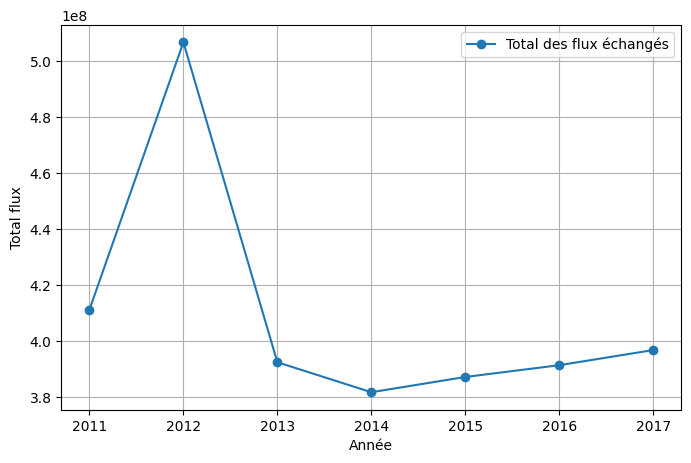

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(flux.index, flux.values, marker="o", linestyle="-", label="Total des flux échangés")
plt.xlabel("Année")
plt.ylabel("Total flux")

plt.legend()
plt.grid()
plt.show()

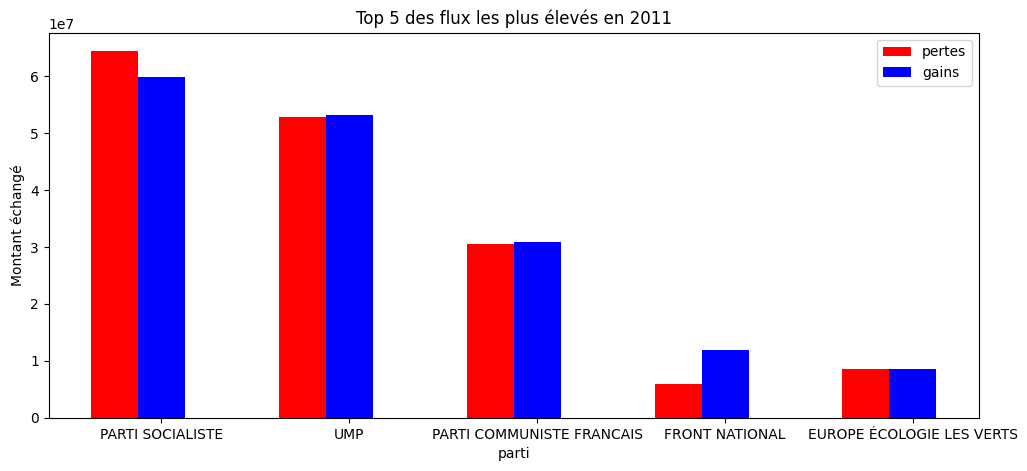

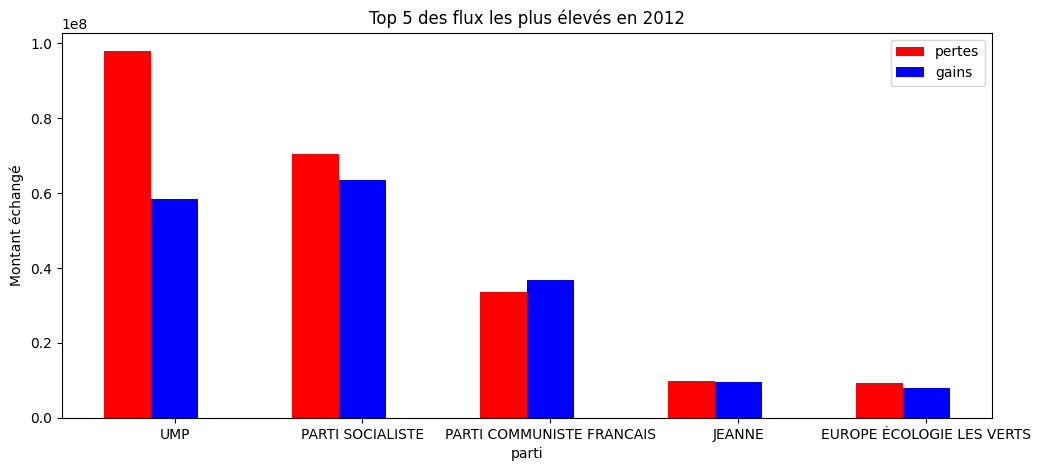

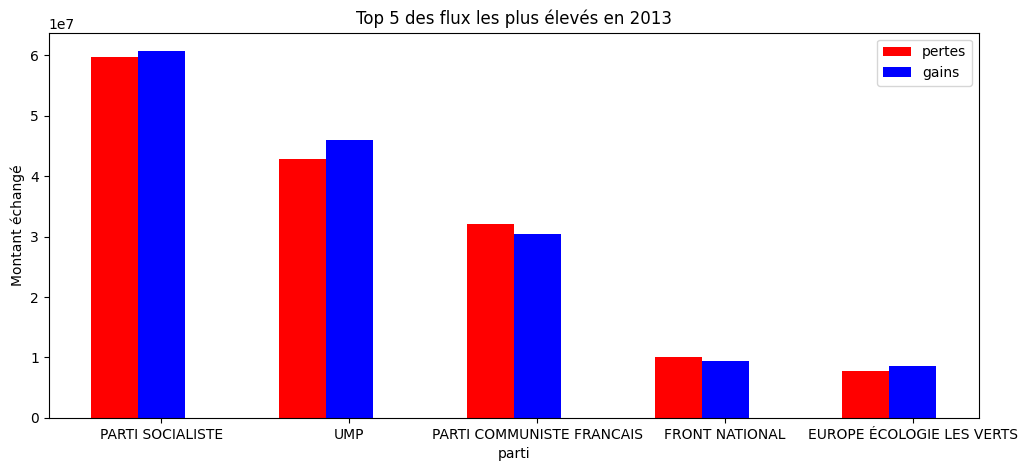

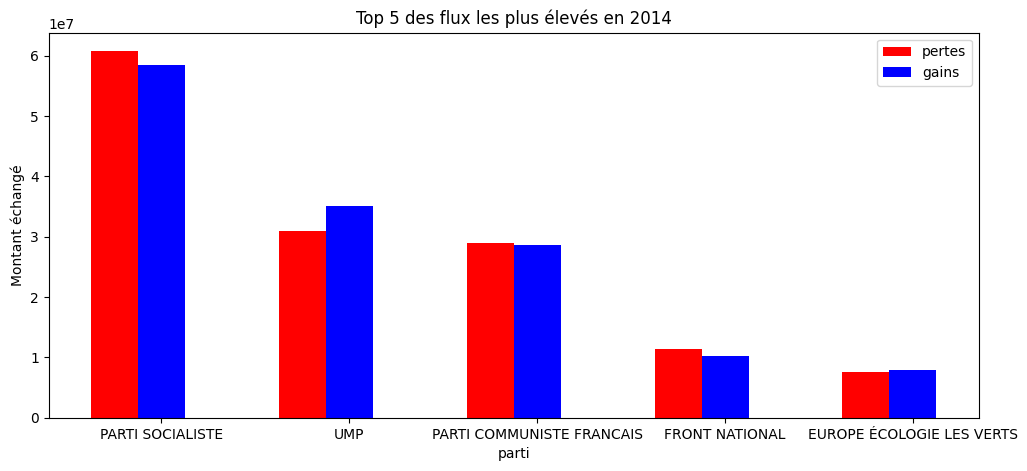

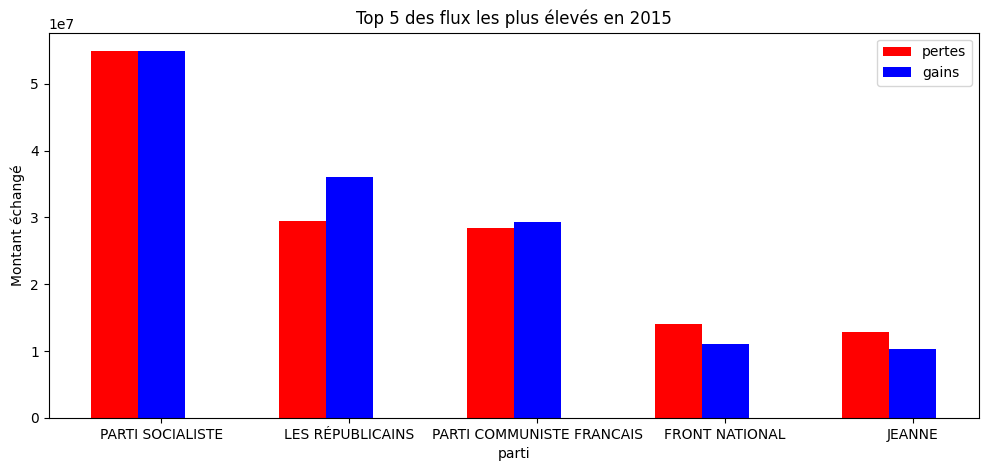

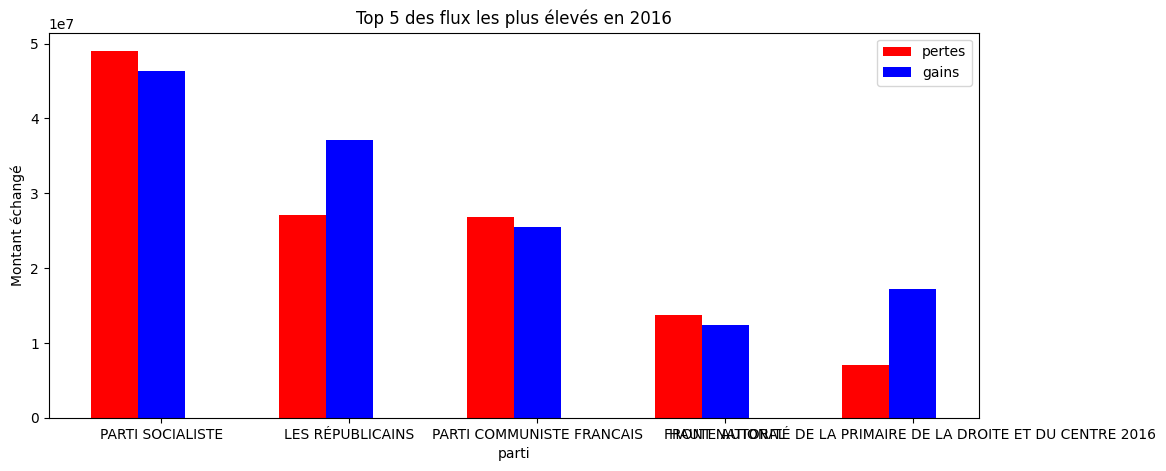

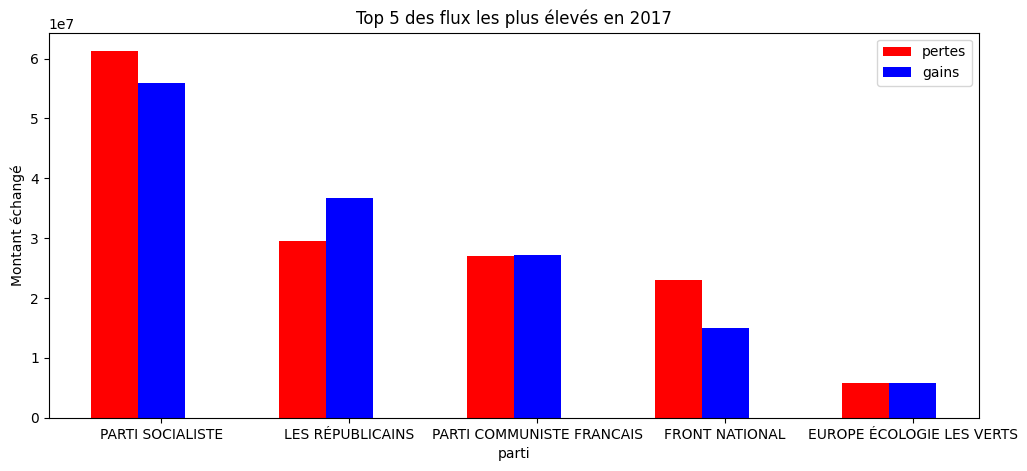

In [13]:
years=sorted(df["année"].unique())
N=5
width=0.25
for year in years:
    df_y=df[df["année"]==year]
    top=df_y.nlargest(N,"total flux monétaire")
    
    plt.figure(figsize=(12, 5))
    
    ind=np.arange(N)
    bar1=plt.bar(ind,top[('CR: CHARGES', 'Total des charges')],width, color="r")
    bar2=plt.bar(ind+width,top[('CR: PRODUITS', 'Total des produits')],width, color="b")
    plt.xlabel("parti")
    plt.ylabel("Montant échangé")
    plt.xticks(ind+width,top[('Nom parti')]) 
    plt.title(f"Top {N} des flux les plus élevés en {year}")
    plt.legend((bar1,bar2),('pertes','gains'))
    plt.show()
   # plt.grid(axis="y", linestyle="--", alpha=0.7)
    

    # Affichage des valeurs sur les barres
   # for i, v in enumerate(top["total flux monétaire"]):
    #    plt.text(i, v + 10, str(v), ha="center", fontsize=12)

In [42]:
top

,Num parti,Nom parti,"(I. - Actif immobilisé, Immobilisations incorporelles)","(I. - Actif immobilisé, Ecart d'acquisition)","(I. - Actif immobilisé, Immobilisations corporelles :)","(I. - Actif immobilisé, - terrains et constructions)","(I. - Actif immobilisé, - autres immobilisations corporelles)","(I. - Actif immobilisé, Immobilisations financières :)","(I. - Actif immobilisé, participations)","(I. - Actif immobilisé, - prêts)",...,"(CR: PRODUITS, Autres produits)","(CR: PRODUITS, Produits financiers)","(CR: PRODUITS, Produits exceptionnels)","(CR: PRODUITS, Reprise sur provisions et amortissements)","(CR: PRODUITS, - reprise sur provisions pour campagnes électorales :)","(CR: PRODUITS, Total des produits)",année,"(CR: CHARGES, Dotations aux amortissements et provisions)",résultat flux monétaire,total flux monétaire
1846,76,PARTI SOCIALISTE,587270.0,0.0,0.0,16593100.0,2077789.0,0.0,1113535.0,9882190.0,...,345815.0,88799.0,849986.0,11308156.0,8243790.0,55879600.0,2017,0.0,-5382462.0,117141662.0
1925,401,LES RÉPUBLICAINS,250380.0,0.0,0.0,32289999.0,2411340.0,0.0,495.0,2307560.0,...,1815725.0,47739.0,432766.0,120315.0,0.0,36721147.0,2017,0.0,7254660.0,66187634.0
1841,60,PARTI COMMUNISTE FRANCAIS,31020.0,0.0,0.0,9822837.0,1488970.0,0.0,361902.0,8903579.0,...,274240.0,1051052.0,6192.0,935537.0,748000.0,27247301.0,2017,0.0,177814.0,54316788.0
1835,40,FRONT NATIONAL,3786.0,0.0,0.0,59760.0,437023.0,0.0,14000.0,10399027.0,...,5175284.0,320448.0,98397.0,30109.0,0.0,15048417.0,2017,0.0,-7883411.0,37980245.0
1854,104,EUROPE ÉCOLOGIE LES VERTS,251431.0,0.0,0.0,0.0,1433248.0,0.0,48230.0,0.0,...,1665.0,9949.0,62876.0,438185.0,400000.0,5813594.0,2017,0.0,16556.0,11610632.0


vérifier les différentes donnations des partis communistes et du parti jeanne à d'autres partis


In [17]:
df_y=df[df["année"]==2016]
top=df_y.nlargest(5,"total flux monétaire")
top.head()

,Num parti,Nom parti,"(I. - Actif immobilisé, Immobilisations incorporelles)","(I. - Actif immobilisé, Ecart d'acquisition)","(I. - Actif immobilisé, Immobilisations corporelles :)","(I. - Actif immobilisé, - terrains et constructions)","(I. - Actif immobilisé, - autres immobilisations corporelles)","(I. - Actif immobilisé, Immobilisations financières :)","(I. - Actif immobilisé, participations)","(I. - Actif immobilisé, - prêts)",...,"(CR: PRODUITS, Autres produits)","(CR: PRODUITS, Produits financiers)","(CR: PRODUITS, Produits exceptionnels)","(CR: PRODUITS, Reprise sur provisions et amortissements)","(CR: PRODUITS, - reprise sur provisions pour campagnes électorales :)","(CR: PRODUITS, Total des produits)",année,"(CR: CHARGES, Dotations aux amortissements et provisions)",résultat flux monétaire,total flux monétaire
1487,76,PARTI SOCIALISTE,577333.0,0.0,0.0,16698895.0,2603970.0,0.0,1064342.0,816040.0,...,455312.0,168678.0,654949.0,738611.0,61596.0,46272810.0,2016,0.0,-2727996.0,95273616.0
1566,401,LES RÉPUBLICAINS,321935.0,0.0,0.0,32900570.0,2981986.0,0.0,0.0,162147.0,...,344082.0,58787.0,267513.0,2084423.0,0.0,37136116.0,2016,0.0,10060964.0,64211268.0
1482,60,PARTI COMMUNISTE FRANCAIS,4700.0,0.0,0.0,8922483.0,2219956.0,0.0,1222104.0,8886738.0,...,397292.0,125404.0,47100.0,734731.0,354000.0,25504601.0,2016,0.0,-1283980.0,52293182.0
1476,40,FRONT NATIONAL,11199.0,0.0,0.0,59760.0,552413.0,0.0,14000.0,2314333.0,...,1594118.0,67920.0,438832.0,31115.0,0.0,12449064.0,2016,0.0,-1322398.0,26220526.0
1776,899,HAUTE AUTORITÉ DE LA PRIMAIRE DE LA DROITE ET ...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,17163337.0,0.0,0.0,0.0,0.0,17163337.0,2016,0.0,10160055.0,24166619.0


In [16]:
b=df[df['Num parti']==899]

In [20]:
charges=[i for i in a.columns if 'CHARGES' in i[0]]

In [19]:
for i in df.columns:
    print(i)

Num parti
Nom parti
('I. - Actif immobilisé', 'Immobilisations incorporelles')
('I. - Actif immobilisé', "Ecart d'acquisition")
('I. - Actif immobilisé', 'Immobilisations corporelles :')
('I. - Actif immobilisé', ' - terrains et constructions')
('I. - Actif immobilisé', ' - autres immobilisations corporelles')
('I. - Actif immobilisé', 'Immobilisations financières :')
('I. - Actif immobilisé', 'participations')
('I. - Actif immobilisé', ' - prêts')
('I. - Actif immobilisé', ' - autres immobilisations financières')
('II. - Actif circulant', 'Stock et en-cours')
('II. - Actif circulant', 'Créances :')
('II. - Actif circulant', '- adhérents et comptes rattachés')
('II. - Actif circulant', ' - autres créances')
('II. - Actif circulant', 'Valeurs mobilières de placement')
('II. - Actif circulant', 'Disponibilités')
('III. - Comptes de régularisation', "Charges constatées d'avance")
('III. - Comptes de régularisation', 'Charges de campagnes électorales à répartir sur plusieurs exercices')
('

In [23]:
years=sorted(df["année"].unique())
N=5
width=0.25
for year in years:
    df_y=df[(df["année"]==year) & (df[df[('III. - Comptes de régularisation', '    Total du passif')]!=0])]
    df_y['rapport actif/passif']=df_y[('III. - Comptes de régularisation', "    Total de l'actif")]/df_y[('III. - Comptes de régularisation', '    Total du passif')]
    top=df_y.nlargest(N,"rapport actif/passif")
    
    plt.figure(figsize=(12, 5))
    
    ind=np.arange(N)
    bar1=plt.bar(ind,top[('rapport actif/passif')],width, color="r")
    #bar2=plt.bar(ind+width,top[('CR: PRODUITS', 'Total des produits')],width, color="b")
    plt.xlabel("parti")
    plt.ylabel("rapport actif/passif")
    plt.xticks(ind+width,top[('Nom parti')]) 
    plt.title(f"Top {N} des rapport actif/passif les plus élevés en {year}")
    #plt.legend((bar1,bar2),('pertes','gains'))
    plt.show()
   # plt.grid(axis="y", linestyle="--", alpha=0.7)
    

    # Affichage des valeurs sur les barres
   # for i, v in enumerate(top["total flux monétaire"]):
    #    plt.text(i, v + 10, str(v), ha="center", fontsize=12)

C:\Users\math\AppData\Local\Temp\ipykernel_3180\1999354932.py:5: RuntimeWarning: '<' not supported between instances of 'int' and 'tuple', sort order is undefined for incomparable objects.
  df_y=df[(df["année"]==year) & (df[df[('III. - Comptes de régularisation', '    Total du passif')]!=0])]


TypeError: unsupported operand type(s) for &: 'bool' and 'str'

In [22]:
df[df[('III. - Comptes de régularisation', '    Total du passif')]==0]

,Num parti,Nom parti,"(I. - Actif immobilisé, Immobilisations incorporelles)","(I. - Actif immobilisé, Ecart d'acquisition)","(I. - Actif immobilisé, Immobilisations corporelles :)","(I. - Actif immobilisé, - terrains et constructions)","(I. - Actif immobilisé, - autres immobilisations corporelles)","(I. - Actif immobilisé, Immobilisations financières :)","(I. - Actif immobilisé, participations)","(I. - Actif immobilisé, - prêts)",...,"(CR: PRODUITS, Autres produits)","(CR: PRODUITS, Produits financiers)","(CR: PRODUITS, Produits exceptionnels)","(CR: PRODUITS, Reprise sur provisions et amortissements)","(CR: PRODUITS, - reprise sur provisions pour campagnes électorales :)","(CR: PRODUITS, Total des produits)",année,"(CR: CHARGES, Dotations aux amortissements et provisions)",résultat flux monétaire,total flux monétaire
239,635,PARIS 2014,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2011,0.0,0.0,0.0
331,283,MOUVEMENT LIBERAL POPULAIRE,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,45799.0,2012,0.0,-443.0,92041.0
666,597,BLOC IDENTITAIRE - MOUVEMENT SOCIAL EUROPEEN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2013,0.0,0.0,0.0
724,688,LE CENTRE POUR LA FRANCE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,932670.0,2013,0.0,0.0,1865340.0
773,756,"SOLIDARITÉ 21e, POUR UNE RECOMPOSITION VRAIMEN...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2013,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2214,1034,UNION DES FRANÇAIS DU MONDE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2017,0.0,0.0,0.0
2219,1039,OSER LA FRANCE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2017,0.0,0.0,0.0
2221,1041,RÉPUBLICAINS CALÉDONIENS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2017,0.0,0.0,0.0
2222,1059,VIVRE LA RÉUNION,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2017,0.0,0.0,0.0
